In [1]:
# Amplitude plot


from matplotlib import patches as ptc
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np
import pickle


In [2]:
data_dir = "../../../data/kagome-02.26.2022-center/"
out_dir = "../../../paper_new/real_space_fig/"

In [15]:
freq = 14.4

with open(data_dir + f"preprocessed_real/_{int(freq*1e3)}.0_0.pkl",'rb') as f:
    real_data = pickle.load(f) 

preamp_gain = 4.731513 #13.5 dB at minimum gain
mic_gain = 0.02 #0.02V/Pa 
    
amp = real_data[:, 2] /preamp_gain/mic_gain
max_idx = np.argmax(amp)
max_amp_flat = amp[max_idx]
phase = real_data[:, 3] - real_data[max_idx, 3]  # phase relative to the max amplitude
x = real_data[:, 0]
y = real_data[:, 1]
value = amp * np.cos(phase/180 * np.pi)

x_unit = 10*np.sqrt(3)/4
y_unit = 7.5
radius = 3.5

x_coords = x * x_unit
y_coords = y * y_unit

print(max_amp_flat)

3.2313976522943086


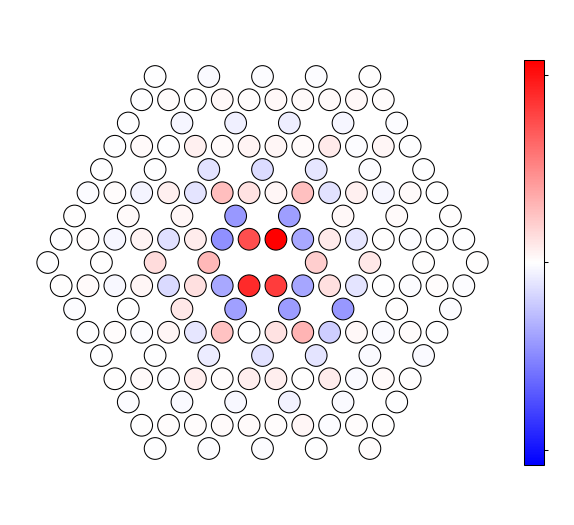

In [16]:
fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
plt.yticks([])
plt.xticks([])
cbar = fig.colorbar(cm.ScalarMappable(norm=colors.Normalize(vmin=-max_amp_flat, vmax=max_amp_flat), cmap = "bwr"), ax=ax, shrink=0.7)

for i in range(len(x_coords)):

    circle = ptc.Ellipse(
        (x_coords[i], y_coords[i]),
        width=radius*2,
        height=radius*2,
        edgecolor='black',
        facecolor=plt.cm.bwr((value[i] + max_amp_flat) / (2 * max_amp_flat)),
        fill=True,
        alpha=1,
        linewidth=0.25
    )
    ax.add_patch(circle)


cbar.set_ticks(np.linspace(-3, 3, 3))
cbar.outline.set_linewidth(0.25)
cbar.ax.set_yticklabels(['','',''])
cbar.ax.tick_params(width=0.25, length = 1)
plt.savefig(out_dir + f"amplitude_plot_{freq}kHz.pdf", bbox_inches='tight')

In [17]:
freq = 4

with open(data_dir + f"preprocessed_real/_{int(freq*1e3)}.0_0.pkl",'rb') as f:
    real_data = pickle.load(f) 

preamp_gain = 4.731513 
mic_gain = 0.02 #0.02V/Pa 
    
amp = real_data[:, 2] /preamp_gain/mic_gain
max_idx = np.argmax(amp)
max_amp_dispersive = amp[max_idx]
phase = real_data[:, 3] - real_data[max_idx, 3]   # phase relative to the max amplitude
x = real_data[:, 0]
y = real_data[:, 1]
value = amp * np.cos(phase/180 * np.pi)

x_unit = 10*np.sqrt(3)/4
y_unit = 7.5
radius = 3.5

x_coords = x * x_unit
y_coords = y * y_unit


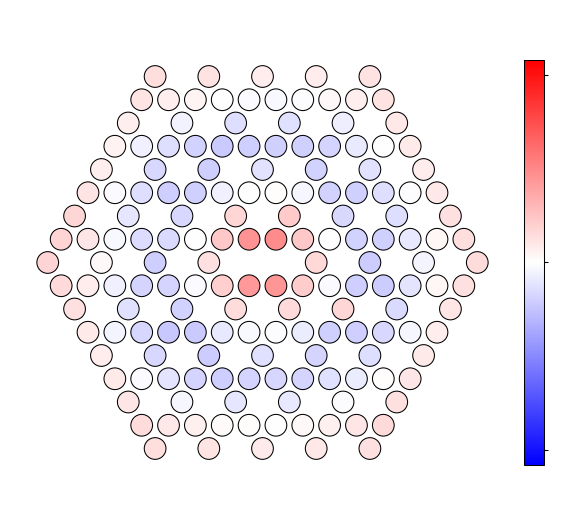

In [18]:
fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
plt.yticks([])
plt.xticks([])
cbar = fig.colorbar(cm.ScalarMappable(norm=colors.Normalize(vmin=-max_amp_flat, vmax=max_amp_flat), cmap = "bwr"), ax=ax, shrink=0.7)

for i in range(len(x_coords)):

    circle = ptc.Ellipse(
        (x_coords[i], y_coords[i]),
        width=radius*2,
        height=radius*2,
        edgecolor='black',
        facecolor=plt.cm.bwr((value[i] + max_amp_flat) / (2 * max_amp_flat)),
        fill=True,
        alpha=1,
        linewidth=0.25
    )
    ax.add_patch(circle)


cbar.set_ticks(np.linspace(-3, 3, 3))
cbar.outline.set_linewidth(0.25)
cbar.ax.set_yticklabels(['','',''])
cbar.ax.tick_params(width=0.25, length = 1)
plt.savefig(out_dir + f"amplitude_plot_{freq}kHz.pdf", bbox_inches='tight')